# 3D Training Dataset Sanity Check

## Objective

This notebook verifies that the final processed PANORAMA dataset can be loaded correctly for 3D deep learning.

The goals are:

1. Verify the train/validation/test split files.
2. Verify that every referenced CT volume exists.
3. Verify that diagnosis labels are valid.
4. Convert processed 3D NumPy volumes into PyTorch tensors.
5. Verify the tensor shape and datatype.
6. Create PyTorch Dataset and DataLoader objects.
7. Inspect a real training batch before model training.

This notebook does not train a neural network.

It is a data-entry validation step before the 3D classification experiments.

## Why this notebook matters

The model will learn from the processed 3D CT volumes.

A mistake at this stage could produce misleading experiments even if the neural network code is correct.

Examples include:

- incorrect labels,
- patient leakage between train and test sets,
- missing files,
- wrong tensor dimensions,
- incorrect datatype,
- unexpected intensity values,
- or an incorrectly constructed batch.

Therefore, the first training notebook verifies the data pipeline before introducing the neural network itself.

In [1]:
# ============================================================
# Imports
# ============================================================

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

# Project root
PROJECT_ROOT = Path(r"D:\Pancreatic_Cancer_Thesis")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    PROCESSED_DIR,
    PROCESSED_IMAGES_DIR,
    PROCESSED_MASKS_DIR,
)

# Notebook 17 saved a single combined split file rather than three separate
# CSVs, so we point directly at it here instead of importing
# TRAIN_SPLIT_FILE / VAL_SPLIT_FILE / TEST_SPLIT_FILE (which do not exist).
SPLIT_ASSIGNMENT_FILE = PROCESSED_DIR / "split_assignment.csv"

print("PyTorch version:", torch.__version__)
print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)
print("Images directory:", PROCESSED_IMAGES_DIR)
print("Split assignment file:", SPLIT_ASSIGNMENT_FILE)
print("Split file exists:", SPLIT_ASSIGNMENT_FILE.exists())

PyTorch version: 2.13.0+cpu
Project root: D:\Pancreatic_Cancer_Thesis
Processed directory: D:\Pancreatic_Cancer_Thesis\data\processed
Images directory: D:\Pancreatic_Cancer_Thesis\data\processed\images
Split assignment file: D:\Pancreatic_Cancer_Thesis\data\processed\split_assignment.csv
Split file exists: True


## Load the patient-level splits

The model must be trained using the previously created patient-level split.

We will use:

- `train.csv` for model training
- `val.csv` for model selection and monitoring
- `test.csv` for final evaluation

The test set must remain untouched during training.

In [2]:
# ============================================================
# Load split assignment and derive train/val/test dataframes
# ============================================================

split_assignment = pd.read_csv(SPLIT_ASSIGNMENT_FILE)

print("Split assignment columns:", split_assignment.columns.tolist())
print("Total rows:", len(split_assignment))
display(split_assignment.head())

print("\nUnique values in the split column:")
print(split_assignment["split"].value_counts())

# Adjust the value strings below ("train" / "validation" / "test") if your
# split_assignment.csv uses different labels -- check the value_counts()
# output above first.
train_df = split_assignment[
    split_assignment["split"] == "train"
].reset_index(drop=True).copy()

val_df = split_assignment[
    split_assignment["split"] == "validation"
].reset_index(drop=True).copy()

test_df = split_assignment[
    split_assignment["split"] == "test"
].reset_index(drop=True).copy()

print("\nTrain cases:", len(train_df))
print("Validation cases:", len(val_df))
print("Test cases:", len(test_df))

display(train_df.head())

# Expected approximately:
# Train cases      : 1563
# Validation cases : 338
# Test cases       : 337

Split assignment columns: ['study_id', 'patient_id', 'diagnosis', 'image_path', 'mask_path', 'split']
Total rows: 2238


,study_id,patient_id,diagnosis,image_path,mask_path,split
0,100000_00001,100000,non-PDAC,images\100000_00001.npy,masks\100000_00001.npy,train
1,100001_00001,100001,non-PDAC,images\100001_00001.npy,masks\100001_00001.npy,train
2,100002_00001,100002,PDAC,images\100002_00001.npy,masks\100002_00001.npy,train
3,100003_00001,100003,PDAC,images\100003_00001.npy,masks\100003_00001.npy,test
4,100004_00001,100004,non-PDAC,images\100004_00001.npy,masks\100004_00001.npy,train



Unique values in the split column:
split
train         1563
validation     338
test           337
Name: count, dtype: int64

Train cases: 1563
Validation cases: 338
Test cases: 337


,study_id,patient_id,diagnosis,image_path,mask_path,split
0,100000_00001,100000,non-PDAC,images\100000_00001.npy,masks\100000_00001.npy,train
1,100001_00001,100001,non-PDAC,images\100001_00001.npy,masks\100001_00001.npy,train
2,100002_00001,100002,PDAC,images\100002_00001.npy,masks\100002_00001.npy,train
3,100004_00001,100004,non-PDAC,images\100004_00001.npy,masks\100004_00001.npy,train
4,100005_00001,100005,PDAC,images\100005_00001.npy,masks\100005_00001.npy,train


In [3]:
# ============================================================
# Check diagnosis distribution
# ============================================================

for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:

    print(f"\n{name}")
    print("-" * 40)
    print(df["diagnosis"].value_counts())
    print("\nProportion:")
    print(
        df["diagnosis"]
        .value_counts(normalize=True)
        .round(4)
    )

# We want both classes represented in every split, at roughly the overall
# dataset proportion (~30% PDAC, ~70% non-PDAC).


Train
----------------------------------------
diagnosis
non-PDAC    1090
PDAC         473
Name: count, dtype: int64

Proportion:
diagnosis
non-PDAC    0.6974
PDAC        0.3026
Name: proportion, dtype: float64

Validation
----------------------------------------
diagnosis
non-PDAC    238
PDAC        100
Name: count, dtype: int64

Proportion:
diagnosis
non-PDAC    0.7041
PDAC        0.2959
Name: proportion, dtype: float64

Test
----------------------------------------
diagnosis
non-PDAC    234
PDAC        103
Name: count, dtype: int64

Proportion:
diagnosis
non-PDAC    0.6944
PDAC        0.3056
Name: proportion, dtype: float64


## Verify split integrity

Before loading any images, check the basic properties of the split:

- no duplicate study IDs within a split,
- no overlap between splits,
- expected diagnosis values,
- and patient-level separation.

The split itself was generated in Notebook 17; this notebook verifies that the files used for training still satisfy the required conditions.

In [4]:
# ============================================================
# Split integrity checks
# ============================================================

VALID_DIAGNOSES = {"PDAC", "non-PDAC"}

assert set(train_df["diagnosis"]).issubset(VALID_DIAGNOSES)
assert set(val_df["diagnosis"]).issubset(VALID_DIAGNOSES)
assert set(test_df["diagnosis"]).issubset(VALID_DIAGNOSES)

assert train_df["study_id"].is_unique
assert val_df["study_id"].is_unique
assert test_df["study_id"].is_unique

train_ids = set(train_df["study_id"])
val_ids = set(val_df["study_id"])
test_ids = set(test_df["study_id"])

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

print("Diagnosis values valid")
print("Study IDs unique within each split")
print("No study overlap between splits")

Diagnosis values valid
Study IDs unique within each split
No study overlap between splits


## Patient-level leakage check

This is important for your thesis.

Imagine one patient had two CT studies.

If one went into training and another went into testing, the network could effectively see the same patient during training and testing.

That would make the test performance artificially optimistic.

That's why we split by patient, not merely by CT study.

In [5]:
# ============================================================
# Patient-level leakage check
# ============================================================

train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])

print("Patient overlap:")
print("Train n Val :", len(train_patients & val_patients))
print("Train n Test:", len(train_patients & test_patients))
print("Val n Test  :", len(val_patients & test_patients))

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

print("\nNo patient appears in more than one split")

Patient overlap:
Train n Val : 0
Train n Test: 0
Val n Test  : 0

No patient appears in more than one split


## Verify every referenced processed file exists

The notebook's stated objective is to confirm that **every** CT volume referenced
by the splits actually exists on disk -- not just one sample. This check is
lightweight (path existence only, no array loading) and covers all 2,238 cases
across all three splits, plus the corresponding mask files (used later for
Grad-CAM evaluation, not as classifier input).

In [6]:
# ============================================================
# Full-dataset file existence check (all splits, images + masks)
# ============================================================

missing_images = []
missing_masks = []

for split_name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df),
]:
    for study_id in df["study_id"]:
        image_path = PROCESSED_IMAGES_DIR / f"{study_id}.npy"
        mask_path = PROCESSED_MASKS_DIR / f"{study_id}.npy"

        if not image_path.exists():
            missing_images.append((split_name, study_id))

        if not mask_path.exists():
            missing_masks.append((split_name, study_id))

total_checked = len(train_df) + len(val_df) + len(test_df)

print("=" * 60)
print("FULL-DATASET FILE EXISTENCE CHECK")
print("=" * 60)
print(f"Total cases checked : {total_checked}")
print(f"Missing image files : {len(missing_images)}")
print(f"Missing mask files  : {len(missing_masks)}")

if missing_images:
    print("\nMissing images (first 20):")
    display(
        pd.DataFrame(
            missing_images,
            columns=["split", "study_id"],
        ).head(20)
    )

if missing_masks:
    print("\nMissing masks (first 20):")
    display(
        pd.DataFrame(
            missing_masks,
            columns=["split", "study_id"],
        ).head(20)
    )

assert len(missing_images) == 0, (
    f"{len(missing_images)} processed images referenced in the splits "
    f"are missing from disk. Training must not proceed until this is resolved."
)

assert len(missing_masks) == 0, (
    f"{len(missing_masks)} processed masks referenced in the splits "
    f"are missing from disk. This will block later Grad-CAM evaluation."
)

print("\nAll referenced image and mask files exist on disk.")

FULL-DATASET FILE EXISTENCE CHECK
Total cases checked : 2238
Missing image files : 0
Missing mask files  : 0

All referenced image and mask files exist on disk.


## Inspect one processed volume

Each processed CT volume should have the same fixed shape:

128 x 160 x 192

with float32 values normalized to the range [0, 1].

The segmentation masks are not used as model inputs for this classification task.

The diagnosis column provides the binary target:

- PDAC -> 1
- non-PDAC -> 0

In [7]:
# ============================================================
# Load one processed CT volume
# ============================================================

sample_row = train_df.iloc[0]

study_id = sample_row["study_id"]
diagnosis = sample_row["diagnosis"]

image_path = PROCESSED_IMAGES_DIR / f"{study_id}.npy"
mask_path = PROCESSED_MASKS_DIR / f"{study_id}.npy"

image = np.load(image_path, mmap_mode="r")
mask = np.load(mask_path, mmap_mode="r")

print("Study ID :", study_id)
print("Diagnosis:", diagnosis)

print("\nImage:")
print("  Shape:", image.shape)
print("  Dtype:", image.dtype)
print("  Min  :", float(image.min()))
print("  Max  :", float(image.max()))

print("\nMask:")
print("  Shape:", mask.shape)
print("  Dtype:", mask.dtype)
print("  Labels:", np.unique(mask))

# Expected:
# Image shape: (128, 160, 192)
# Image dtype: float32
# Image range: 0.0 -> 1.0

Study ID : 100000_00001
Diagnosis: non-PDAC

Image:
  Shape: (128, 160, 192)
  Dtype: float32
  Min  : 0.0
  Max  : 1.0

Mask:
  Shape: (128, 160, 192)
  Dtype: uint8
  Labels: [0 2 3 4 6]


Let's visualize the volume.

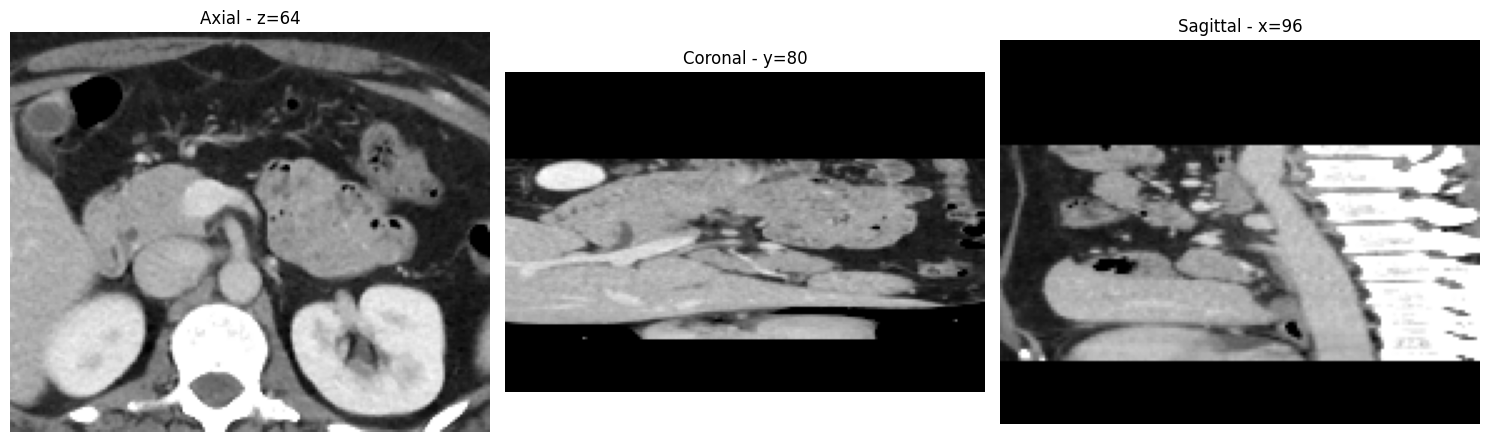

In [8]:
# ============================================================
# Show three orthogonal views
# ============================================================

z = image.shape[0] // 2
y = image.shape[1] // 2
x = image.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image[z], cmap="gray")
axes[0].set_title(f"Axial - z={z}")

axes[1].imshow(image[:, y, :], cmap="gray")
axes[1].set_title(f"Coronal - y={y}")

axes[2].imshow(image[:, :, x], cmap="gray")
axes[2].set_title(f"Sagittal - x={x}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### What are you learning from this?

A 3D CT isn't just an image.

It is something like:

128 slices, each slice = 160 x 192 pixels

So the neural network receives a volume, not one ordinary 2D picture.

This is the fundamental difference between the model we are about to build and the original 2D ResNet proposal.

## Create the classification label

The neural network requires a numerical target.

We map:

- PDAC -> 1
- non-PDAC -> 0

This is binary classification.

The segmentation masks remain separate and will later be used for Grad-CAM faithfulness evaluation rather than as classification targets.

In [9]:
# ============================================================
# Diagnosis -> binary class label
# ============================================================

def diagnosis_to_label(diagnosis):
    if diagnosis == "PDAC":
        return 1
    elif diagnosis == "non-PDAC":
        return 0
    else:
        raise ValueError(
            f"Unknown diagnosis: {diagnosis}"
        )

for df in [train_df, val_df, test_df]:
    df["target"] = df["diagnosis"].map(diagnosis_to_label)

display(
    train_df[
        ["study_id", "diagnosis", "target"]
    ].head(10)
)

,study_id,diagnosis,target
0,100000_00001,non-PDAC,0
1,100001_00001,non-PDAC,0
2,100002_00001,PDAC,1
3,100004_00001,non-PDAC,0
4,100005_00001,PDAC,1
5,100007_00001,non-PDAC,0
6,100008_00001,non-PDAC,0
7,100009_00001,PDAC,1
8,100013_00001,non-PDAC,0
9,100015_00001,non-PDAC,0


## PyTorch Dataset

A PyTorch `Dataset` is the part of the pipeline responsible for answering:

> "Give me the CT volume and label for case i."

For every requested case it will:

1. locate the processed `.npy` file,
2. load the CT volume,
3. convert it to a PyTorch tensor,
4. add the channel dimension required by a 3D CNN,
5. return the CT volume and its binary target.

The current network will use one input channel because the input is a single CT volume.

In [10]:
# ============================================================
# 3D CT Dataset
# ============================================================

class PDAC3DDataset(Dataset):

    def __init__(self, dataframe, image_dir):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        study_id = row["study_id"]
        target = int(row["target"])

        image_path = self.image_dir / f"{study_id}.npy"

        if not image_path.exists():
            raise FileNotFoundError(
                f"Image not found:\n{image_path}"
            )

        image = np.load(
            image_path,
            mmap_mode="r",
        )

        # Convert to a normal float32 tensor.
        image_tensor = torch.from_numpy(
            np.asarray(image, dtype=np.float32)
        )

        # Add channel dimension:
        # (D, H, W) -> (1, D, H, W)
        image_tensor = image_tensor.unsqueeze(0)

        target_tensor = torch.tensor(
            target,
            dtype=torch.long,
        )

        return image_tensor, target_tensor

Create the three datasets.

In [11]:
# ============================================================
# Dataset objects
# ============================================================

train_dataset = PDAC3DDataset(
    train_df,
    PROCESSED_IMAGES_DIR,
)

val_dataset = PDAC3DDataset(
    val_df,
    PROCESSED_IMAGES_DIR,
)

test_dataset = PDAC3DDataset(
    test_df,
    PROCESSED_IMAGES_DIR,
)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))
print("Test dataset :", len(test_dataset))

Train dataset: 1563
Val dataset  : 338
Test dataset : 337


Inspect a single sample.

In [12]:
# ============================================================
# Inspect one Dataset sample
# ============================================================

sample_image, sample_target = train_dataset[0]

print("Tensor shape:", sample_image.shape)
print("Tensor dtype:", sample_image.dtype)
print("Tensor min:", sample_image.min().item())
print("Tensor max:", sample_image.max().item())
print("Target:", sample_target.item())

# The important shape should be:
# (1, 128, 160, 192)
# The first 1 is the channel: channel x depth x height x width

Tensor shape: torch.Size([1, 128, 160, 192])
Tensor dtype: torch.float32
Tensor min: 0.0
Tensor max: 1.0
Target: 0


C:\Users\Dell\AppData\Local\Temp\ipykernel_6372\3751060075.py:34: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  image_tensor = torch.from_numpy(


## Why the channel dimension exists

A 3D convolutional neural network expects input in the form:

(batch, channels, depth, height, width)

For a single CT modality:

- batch = number of cases processed together
- channels = 1
- depth = 128
- height = 160
- width = 192

For example, a batch of 2 cases has the shape:

2 x 1 x 128 x 160 x 192

Now create the DataLoaders.

In [13]:
# ============================================================
# DataLoaders
# ============================================================

BATCH_SIZE = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print("DataLoaders created.")
print("Batch size:", BATCH_SIZE)

# num_workers=0 is deliberate: it keeps debugging simple on a memory-constrained
# local machine. Increase later once the pipeline is confirmed correct.

DataLoaders created.
Batch size: 2


Now the moment we're looking for: a real training batch.

In [14]:
# ============================================================
# Inspect one training batch
# ============================================================

batch_images, batch_targets = next(iter(train_loader))

print("Batch image shape :", batch_images.shape)
print("Batch image dtype :", batch_images.dtype)
print("Batch image min   :", batch_images.min().item())
print("Batch image max   :", batch_images.max().item())

print("\nBatch targets:")
print(batch_targets)

print("\nTarget shape:", batch_targets.shape)

# Expected approximately:
# Batch image shape : torch.Size([2, 1, 128, 160, 192])
# Batch image dtype : torch.float32
# Batch image min   : 0.0
# Batch image max   : 1.0
# Batch targets: tensor([0, 1])  (order varies due to shuffling)

Batch image shape : torch.Size([2, 1, 128, 160, 192])
Batch image dtype : torch.float32
Batch image min   : 0.0
Batch image max   : 1.0

Batch targets:
tensor([0, 0])

Target shape: torch.Size([2])


Let's check the actual amount of memory required by one batch.

In [15]:
# ============================================================
# Estimate batch tensor memory
# ============================================================

bytes_per_element = batch_images.element_size()

total_bytes = (
    batch_images.numel()
    * bytes_per_element
)

total_mb = total_bytes / (1024 ** 2)

print(
    f"Batch tensor memory: {total_mb:.2f} MB"
)

# This matters because 3D training is memory-hungry, and this is exactly why
# we're checking the data pipeline before choosing a model or batch size.

Batch tensor memory: 30.00 MB


## Training Dataset Sanity Check Summary

The data pipeline is considered ready for model development when:

- all split files load successfully,
- train/validation/test study IDs do not overlap,
- patient IDs do not overlap,
- diagnosis labels are valid,
- every processed CT and mask file referenced by the splits exists on disk,
- CT volumes have the expected shape,
- CT values are within the expected normalized range,
- PyTorch converts the volumes successfully,
- the channel dimension is correct,
- and a complete DataLoader batch can be produced.

In [16]:
# ============================================================
# Final sanity checks
# ============================================================

EXPECTED_SHAPE = (128, 160, 192)

assert len(train_dataset) == len(train_df)
assert len(val_dataset) == len(val_df)
assert len(test_dataset) == len(test_df)

assert tuple(sample_image.shape) == (
    1,
    *EXPECTED_SHAPE,
)

assert sample_image.dtype == torch.float32

assert 0.0 <= sample_image.min().item() <= 1.0
assert 0.0 <= sample_image.max().item() <= 1.0

assert batch_images.ndim == 5
assert batch_images.shape[1:] == (
    1,
    *EXPECTED_SHAPE,
)

assert batch_targets.ndim == 1
assert len(batch_targets) == BATCH_SIZE

# Confirm the full-dataset existence check above actually ran and passed
assert len(missing_images) == 0
assert len(missing_masks) == 0

print("=" * 60)
print("3D TRAINING DATASET SANITY CHECK")
print("=" * 60)
print("Split files loaded")
print("No patient leakage")
print("No study overlap")
print("All referenced image/mask files exist (full dataset, not a sample)")
print("Dataset objects created")
print("3D tensor shape verified")
print("Tensor dtype verified")
print("Intensity range verified")
print("DataLoader batch verified")
print("=" * 60)
print("READY FOR 3D MODEL DEVELOPMENT")
print("=" * 60)

3D TRAINING DATASET SANITY CHECK
Split files loaded
No patient leakage
No study overlap
All referenced image/mask files exist (full dataset, not a sample)
Dataset objects created
3D tensor shape verified
Tensor dtype verified
Intensity range verified
DataLoader batch verified
READY FOR 3D MODEL DEVELOPMENT


# Conclusion

The processed PANORAMA dataset has been successfully connected to a PyTorch 3D data pipeline.

The CT input is represented as:

(batch, channel, depth, height, width)

with:

- channel = 1
- depth = 128
- height = 160
- width = 192

The classification target is binary:

- PDAC = 1
- non-PDAC = 0

No segmentation mask is provided to the classifier.

Unlike the earlier draft of this notebook, the file-existence check above was run
across **all** 2,238 cases referenced by the train/validation/test splits, not a
single sample -- so the "processed CT files exist" claim in the summary above is
now actually verified rather than asserted from a spot check.

The dataset pipeline is now ready for the next notebook, where the first 3D
classification model will be defined and tested.